# 07-2. 검색 결과를 뉴스 리포트로 정리하기

이 실습은 1단계 검색 그래프에 LLM 리포트 작성 노드를 추가하는 예제이다.

## 학습 목표

1. 검색 노드와 리포트 작성 노드를 순차적으로 연결한다.
2. Tavily 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한다.
3. LLM이 검색 결과를 바탕으로 뉴스 리포트를 생성하도록 구성한다.
4. `START → 검색 → 리포트작성 → END` 흐름을 이해한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```


## 0. 설치 패키지

이 실습은 LangGraph, OpenAI 모델, Tavily 검색 도구를 사용한다.  
처음 실행하는 환경에서는 아래 명령으로 필요한 패키지를 설치한다.

```bash
uv add langgraph langchain-openai langchain-tavily langchain-core python-dotenv grandalf
```

`.env` 파일에는 다음 값을 설정한다.

```text
nvidiaapi_key=발급받은_NVIDIA_API_Key
TAVILY_API_KEY=발급받은_Tavily_API_Key
```


In [12]:
# 공통 환경 설정
# - .env 파일에서 API Key를 읽는다.
# - API Key가 없으면 실습 초반에 명확한 오류를 발생시킨다.
import os
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../.env")

NVIDIA_API_KEY = os.getenv("NVIDIA_KEY2")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not NVIDIA_API_KEY:
    raise ValueError("nvidiaapi_key가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

print("환경 변수 로드 완료")


환경 변수 로드 완료


In [13]:
# LangGraph, LLM, Tavily 검색 도구를 불러온다.
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Image, display

# LLM은 검색 결과를 자연어 리포트로 정리할 때 사용한다.
llm = ChatOpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    model="nvidia/nemotron-3-ultra-550b-a55b",
    api_key=os.getenv("NVIDIA_KEY2"),
    temperature=0.2,
    timeout=1200,   # 기본값보다 넉넉하게
)

# TavilySearch는 외부 웹 검색을 수행하는 도구이다.
tavily_tool = TavilySearch(max_results=5)


In [14]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 검색 결과를 list[dict] 형태로 정리한다.

    TavilySearch의 반환값은 보통 {"results": [...]} 형태이다.
    실습에서는 이후 노드가 사용하기 쉽도록 검색 결과 리스트만 추출한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def format_search_results(results: list[dict]) -> str:
    """검색 결과를 LLM 프롬프트에 넣기 쉬운 문자열로 변환한다."""
    if not results:
        return "검색 결과가 없다."

    lines = []
    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


def show_graph(app):
    """그래프 구조를 시각화한다.

    Mermaid 이미지 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())


## 1. State 정의

2단계에서는 검색 결과를 바탕으로 최종 리포트를 생성한다.  
따라서 `report` 필드를 추가한다.

| 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 주제 |
| `search_query` | 실제 검색어 |
| `search_results` | Tavily 검색 결과 |
| `report` | LLM이 작성한 최종 리포트 |


In [15]:
class ReportState(TypedDict):
    # 사용자가 입력한 원래 주제이다.
    topic: str

    # Tavily 검색에 사용한 검색어이다.
    search_query: str

    # Tavily에서 받은 검색 결과 목록이다.
    search_results: list[dict]

    # LLM이 작성한 뉴스 리포트이다.
    report: str


## 2. 검색 노드 정의

1단계와 동일하게 Tavily 검색을 수행한다.  
검색 노드는 `search_query`와 `search_results`를 반환한다.


In [16]:
def search_node(state: ReportState) -> dict:
    """Tavily 검색을 수행하는 노드이다."""

    query = state["topic"]
    print(f"검색어: {query}")

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"검색 결과 수: {len(results)}")

    return {
        "search_query": query,
        "search_results": results,
    }


## 3. 리포트 작성 체인 정의

LLM은 검색 결과 리스트를 직접 이해하기 어렵다.  
따라서 `format_search_results()` 함수로 검색 결과를 문자열로 바꾼 뒤 프롬프트에 넣는다.

날짜, 수치, 기관명은 검색 결과에 있는 경우에만 사용한다.  
제공되지 않은 정보는 추정하지 않는다.


In [17]:
report_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
너는 검색 결과를 바탕으로 짧은 뉴스 브리핑을 작성하는 AI이다.

작성 규칙:
1. 검색 결과에 있는 내용만 사용한다.
2. 날짜, 수치, 기관명은 원문에 있을 때만 사용한다.
3. 제공되지 않은 정보는 추정하지 않는다.
4. 한국어로 작성한다.
5. 제목, 핵심 요약, 주요 내용, 참고 링크 순서로 정리한다.
""".strip(),
    ),
    (
        "human",
        """
주제: {topic}

검색 결과:
{search_results}

위 검색 결과를 바탕으로 초보자도 이해할 수 있는 뉴스 리포트를 작성하라.
""".strip(),
    ),
])

# 프롬프트 → LLM → 문자열 출력 파서 순서로 실행되는 LangChain 체인이다.
report_chain = report_prompt | llm | StrOutputParser()


## 4. 리포트 작성 노드 정의

이 노드는 검색 결과를 받아 LLM 리포트를 생성한다.

입력으로 사용하는 State 값은 다음과 같다.

- `topic`
- `search_results`

반환하는 State 값은 다음과 같다.

- `report`


In [18]:
def report_node(state: ReportState) -> dict:
    """검색 결과를 바탕으로 뉴스 리포트를 작성하는 노드이다."""

    # 검색 결과를 프롬프트에 넣기 좋은 문자열로 변환한다.
    search_text = format_search_results(state["search_results"])

    # LLM 체인을 실행해 리포트를 생성한다.
    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}


## 5. 그래프 구성

검색 노드 다음에 리포트 작성 노드를 연결한다.

```text
START → 검색 → 리포트작성 → END
```


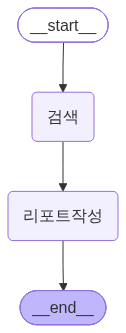

In [19]:
builder = StateGraph(ReportState)

# 두 개의 노드를 등록한다.
builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

# 순차 실행 흐름을 정의한다.
builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()

show_graph(app)


## 6. 그래프 실행

최종 결과에서 `report` 값을 확인한다.


In [20]:
result = app.invoke({
    "topic": "인공지능 최신 동향",
    "search_query": "",
    "search_results": [],
    "report": "",
})

print(result["report"])


검색어: 인공지능 최신 동향
검색 결과 수: 5
**제목: 2025~2026년 인공지능(AI) 최신 동향: '에이전틱 AI' 중심의 실질적 통합·확장기 진입**

**핵심 요약**
생성형 AI 등장 이후 급성장하던 AI 시장이 2025~2026년을 기점으로 '도입기'를 넘어 '혁신·통합기'로 진입하고 있다. 글로벌 시장 규모는 2023년 2,146억 달러에서 2030년 1조 3,391억 달러(연평균 35.7% 성장)로 전망되며, 핵심 트렌드는 **'에이전틱 AI(Agentic AI)'**의 부상이다. AI는 반응형 챗봇에서 벗어나 목표 지향적·자율적으로 업무를 수행하는 '에이전트' 형태로 진화 중이며, 기업 내부 업무 자동화와 레거시 시스템 연동이 본격화되고 있다. 동시에 미국·EU·일본 등 주요국은 AI 안전·거버넌스 체계를 법제도화하며 신뢰성 확보에 주력하고 있다.

---

**주요 내용**

**1. 시장 규모 및 성장 전망**
*   **글로벌 시장 규모:** 2023년 기준 **2,146억 달러** 기록. 2030년까지 **1조 3,391억 달러** 규모로 연평균 **35.7%** 고성장 전망 (ETRI, 가트너 인용) [1].
*   **생성형 AI 시장:** 2026년 **833억 달러** 규모, 연 **31.6%** 성장 예상 (Salesforce/캐럿글로벌 자료 인용) [2].

**2. 핵심 기술 트렌드: '에이전틱 AI(Agentic AI)'와 '에이전틱 엔터프라이즈'**
*   **패러다임 전환:** 2024~2025년 '반응형·범용 LLM·불확실성·사람 중심'에서 2026년 **'선제적(목표 위임형)·도메인 특화·측정 가능한 신뢰성·사람·에이전트·시스템 혼합'** 구조로 임계점 돌파 [2].
*   **주요 기관 전망:** 가트너(Gartner)는 **2025년 10대 전략 기술 트렌드** 1순위로 '에이전틱 AI', 'AI 거버넌스 플랫폼' 선정 [1]. 맥킨지(McKinsey), IBM, 포레스터(Forrester) 등도 2025년

## 7. stream으로 단계별 실행 확인

`stream()`을 사용하면 검색 노드와 리포트 작성 노드가 각각 어떤 값을 반환하는지 확인할 수 있다.


In [21]:
for event in app.stream(
    {
        "topic": "생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기",
        "search_query": "",
        "search_results": [],
        "report": "",
    },
    stream_mode="updates",
):
    # print(event)
    # for update_data in event.values():
    #     print(update_data)
    for update_data in event.values():
        if "search_results" in update_data:
            for i, item in enumerate(update_data["search_results"], start=1):
                print(f"\n[{i}] {item.get('title')}")
                print(item.get("url"))
                print(item.get("content"))

검색어: 생성형 AI 교육 트렌드, url 오픈 가능한 자료만 추출하기
검색 결과 수: 5

[1] 교육 분야에서 생성형 AI를 활용하는 10가지 주요 사례 | 가이드
https://www.hdwebsoft.com/ko/blog/top-10-use-cases-of-generative-ai-in-education
방대한 데이터 세트를 실시간으로 분석할 수 있는 능력을 갖춘 생성형 AI는 교육에 상당한 이점을 제공합니다. 예를 들어, 교육 기관은 이를 통해 학습 패턴을 효과적으로 파악할 수 있습니다. 또한, 학생 성과를 정확하게 평가하고 다양한 학생 요구에 맞춰 교육 전략을 동적으로 조정할 수 있습니다. 교육에 생성형 AI를 도입하면 운영을 최적화할 뿐만 아니라 혁신적인 교수법을 도입할 수 있습니다. 궁극적으로 AI를 통해 학습은 더욱 흥미롭고 효과적이게 됩니다.

교육 분야의 생성형 AI 시장은 빠르게 성장하고 있습니다. 최근 추산에 따르면 전 세계 교육 AI 시장 규모는 189억 2,400만 달러에 달합니다. 2025년에는 개인 맞춤형 학습 솔루션과 고급 교육 도구에 대한 수요가 증가할 것으로 예상됩니다. 이러한 급증세는 생성형 AI(GenAI)가 교육 제공 및 소비 방식을 재정의하며 보여주는 혁신적인 잠재력을 강조합니다.

## 교육 분야에서 생성형 AI의 이점 [...] GenAI(생성형 AI)는 텍스트, 이미지, 비디오, 심지어 소프트웨어 코드와 같은 콘텐츠를 생성할 수 있는 고급 머신러닝 모델을 의미합니다. 교육 분야에서 이 기술은 기존의 교육 및 학습 과정을 혁신할 수 있는 능력으로 주목받고 있습니다. 특히, 개별 학생의 요구에 맞춘 맞춤형 학습 경험을 개발하고 고품질 교육 자료를 생성하는 데 활용되고 있습니다. 또한, 교육자들이 행정 업무를 더욱 효율적으로 관리할 수 있도록 지원하여 전반적인 생산성과 효율성을 향상시킵니다. [...] ### 오래된 학습 자료 복원

또한, 교육 분야의 생성형 AI는 오래되었거나 손상된 교육 자료에 새로운 생명을 불어

OpenAIAPIError: Error code: 504

## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 하나의 그래프 안에서 외부 검색과 LLM 생성을 순차적으로 연결할 수 있다.
2. 검색 결과는 LLM이 이해할 수 있도록 문자열로 정리해야 한다.
3. LangGraph의 각 노드는 자신이 담당하는 작업만 수행하고, 변경할 State 값만 반환한다.
4. 다음 단계에서는 검색 결과가 부족할 때 다시 검색하는 조건부 흐름을 추가한다.


---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. 검색 결과를 LLM 입력용 문자열로 변환
def format_search_results(results: list[dict]) -> str:
    if not results:
        return "검색 결과가 없다."

    lines = []

    for idx, item in enumerate(results, start=1):
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "내용 없음")

        lines.append(
            f"[{idx}] {title}\n"
            f"URL: {url}\n"
            f"내용: {content}"
        )

    return "\n\n".join(lines)


# 3. State 정의
from typing_extensions import TypedDict

class ReportState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    report: str


# 4. 검색 노드
def search_node(state: ReportState) -> dict:
    query = state["topic"]

    raw_result = tavily_tool.invoke({"query": query})
    results = raw_result["results"]

    return {
        "search_query": query,
        "search_results": results,
    }


# 5. 리포트 작성 노드
def report_node(state: ReportState) -> dict:
    search_text = format_search_results(state["search_results"])

    report = report_chain.invoke({
        "topic": state["topic"],
        "search_results": search_text,
    })

    return {"report": report}


# 6. 그래프 구성
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ReportState)

builder.add_node("검색", search_node)
builder.add_node("리포트작성", report_node)

builder.add_edge(START, "검색")
builder.add_edge("검색", "리포트작성")
builder.add_edge("리포트작성", END)

app = builder.compile()
```

- 노드 설명 
   
| 노드 | 역할 |
|---|---|
| 검색 | 사용자의 주제를 검색어로 사용해 Tavily Search API로 웹 검색을 수행한다. |
| 리포트작성 | 검색 결과를 LLM 프롬프트에 넣기 좋은 문자열로 변환한 뒤 뉴스 리포트를 생성한다. |

- State 필드 설명    

| State 필드 | 의미 |
|---|---|
| `topic` | 사용자가 알고 싶은 원래 주제이다. |
| `search_query` | 실제 Tavily 검색에 사용한 검색어이다. |
| `search_results` | Tavily에서 반환한 검색 결과 목록이다. |
| `report` | LLM이 검색 결과를 바탕으로 작성한 최종 리포트이다. |

이 실습은 LangGraph에서 **외부 검색 API 호출 결과를 LLM 생성 노드로 전달하는 기본 파이프라인** 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
리포트작성
  ↓
END
```

즉, 07-1이 “검색 도구를 노드로 연결하는 실습”이라면, 07-2는 여기에 **LLM 후처리 노드**를 추가해 검색 결과를 사람이 읽기 쉬운 리포트로 변환하는 실습이다.